<a href="https://colab.research.google.com/github/Mant-0957/FiNaL_DATAPRE/blob/main/FiNaL_DATAPRE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import json

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import zscore
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings("ignore")

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [4]:
import sqlite3

# Load CSV
users = pd.read_csv("/content/users - users.csv")

# Load JSON
sales = pd.read_json("/content/sales.json")

# Load SQL
# Connect to an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Read the SQL script
with open("/content/inventory.sql","r") as f:
    sql_script = f.read()

# Execute the SQL script to create tables and insert data
conn.executescript(sql_script)

# Read the data from the in-memory database
inventory = pd.read_sql("SELECT * FROM products;", conn)

# Close the connection
conn.close()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [5]:
print("Users Dataset")
display(users.head())

print("Sales Dataset")
display(sales.head())

print("Inventory Dataset")
display(inventory.head())

Users Dataset


,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30,Other,Chennai,2024-01-04


Sales Dataset


,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04


Inventory Dataset


,product_id,product_name,category,price,stock
0,P001,Product_001,Grocery,264.89,371
1,P002,Product_002,Grocery,605.91,150
2,P003,Product_003,Beauty,3027.98,127
3,P004,Product_004,Toys,2600.12,229
4,P005,Product_005,Books,1178.99,18


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [6]:
print("Users Info")
users.info()

print("\nSales Info")
sales.info()

print("\nInventory Info")
inventory.info()

Users Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            200 non-null    object
 1   name               200 non-null    object
 2   age                200 non-null    int64 
 3   gender             200 non-null    object
 4   city               200 non-null    object
 5   registration_date  200 non-null    object
dtypes: int64(1), object(5)
memory usage: 9.5+ KB

Sales Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1000 non-null   object        
 1   user_id         1000 non-null   object        
 2   product_id      1000 non-null   object        
 3   amount          1000 non-null   float64       
 4   payment_type    1000 non-

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [7]:
print("Users Missing Values")
print(users.isnull().sum())

print("\nSales Missing Values")
print(sales.isnull().sum())

print("\nInventory Missing Values")
print(inventory.isnull().sum())

Users Missing Values
user_id              0
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64

Sales Missing Values
transaction_id    0
user_id           0
product_id        0
amount            0
payment_type      0
date              0
dtype: int64

Inventory Missing Values
product_id      0
product_name    0
category        0
price           0
stock           0
dtype: int64


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [8]:
print(users.dtypes)

print(sales.dtypes)

print(inventory.dtypes)

user_id              object
name                 object
age                   int64
gender               object
city                 object
registration_date    object
dtype: object
transaction_id            object
user_id                   object
product_id                object
amount                   float64
payment_type              object
date              datetime64[ns]
dtype: object
product_id       object
product_name     object
category         object
price           float64
stock             int64
dtype: object


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [9]:
print("Users Duplicate :",users.duplicated().sum())

print("Sales Duplicate :",sales.duplicated().sum())

print("Inventory Duplicate :",inventory.duplicated().sum())

Users Duplicate : 0
Sales Duplicate : 0
Inventory Duplicate : 0


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [10]:
users.describe()

,age
count,200.000000
mean,31.260000
std,7.270951
min,18.000000
25%,26.000000
50%,31.500000
75%,35.250000
max,53.000000


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [11]:
sales.describe()

,amount,date
count,1000.000000,1000
mean,67.599040,2024-06-11 23:15:21.600000
min,7.810000,2023-01-01 00:00:00
25%,37.745000,2023-09-24 12:00:00
50%,56.390000,2024-06-14 12:00:00
75%,82.935000,2025-02-26 06:00:00
max,550.950000,2025-11-01 00:00:00
std,45.411375,NaN


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [12]:
inventory.describe()

,price,stock
count,50.000000,50.000000
mean,2422.600600,225.720000
std,1282.179882,141.827581
min,128.310000,18.000000
25%,1456.655000,128.750000
50%,2449.910000,202.500000
75%,3401.080000,306.750000
max,4970.990000,496.000000


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [13]:
# Numerical columns
user_num = users.select_dtypes(include=np.number).columns
sales_num = sales.select_dtypes(include=np.number).columns
inventory_num = inventory.select_dtypes(include=np.number).columns

# Categorical columns
user_cat = users.select_dtypes(include='object').columns
sales_cat = sales.select_dtypes(include='object').columns
inventory_cat = inventory.select_dtypes(include='object').columns

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [14]:
num_imputer = SimpleImputer(strategy="mean")

users[user_num] = num_imputer.fit_transform(users[user_num])

sales[sales_num] = num_imputer.fit_transform(sales[sales_num])

inventory[inventory_num] = num_imputer.fit_transform(inventory[inventory_num])

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [15]:
cat_imputer = SimpleImputer(strategy="most_frequent")

users[user_cat] = cat_imputer.fit_transform(users[user_cat])

sales[sales_cat] = cat_imputer.fit_transform(sales[sales_cat])

inventory[inventory_cat] = cat_imputer.fit_transform(inventory[inventory_cat])

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [16]:
knn = KNNImputer(n_neighbors=5)

users[user_num] = knn.fit_transform(users[user_num])

sales[sales_num] = knn.fit_transform(sales[sales_num])

inventory[inventory_num] = knn.fit_transform(inventory[inventory_num])

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [17]:
users.drop_duplicates(inplace=True)

sales.drop_duplicates(inplace=True)

inventory.drop_duplicates(inplace=True)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [18]:
sales["amount"] = sales["amount"].abs()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [19]:
print(users.isnull().sum())

print(sales.isnull().sum())

print(inventory.isnull().sum())

user_id              0
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64
transaction_id    0
user_id           0
product_id        0
amount            0
payment_type      0
date              0
dtype: int64
product_id      0
product_name    0
category        0
price           0
stock           0
dtype: int64


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [20]:
Q1 = sales["amount"].quantile(0.25)
Q3 = sales["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = sales[
    (sales["amount"] < lower) |
    (sales["amount"] > upper)
]

print("Number of Outliers (IQR):", len(iqr_outliers))

Number of Outliers (IQR): 53


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [21]:
sales_iqr = sales[
    (sales["amount"] >= lower) &
    (sales["amount"] <= upper)
]

print("Shape Before :", sales.shape)
print("Shape After  :", sales_iqr.shape)

Shape Before : (1000, 6)
Shape After  : (947, 6)


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [22]:
print("Original Records :", len(sales))
print("After IQR :", len(sales_iqr))

Original Records : 1000
After IQR : 947


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [23]:
from scipy.stats.mstats import winsorize

sales["amount_winsor"] = winsorize(
    sales["amount"],
    limits=[0.05, 0.05]
)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [24]:
print("Original Amount")

print(sales["amount"].describe())

print("\nWinsorized Amount")

print(sales["amount_winsor"].describe())

Original Amount
count    1000.000000
mean       67.599040
std        45.411375
min         7.810000
25%        37.745000
50%        56.390000
75%        82.935000
max       550.950000
Name: amount, dtype: float64

Winsorized Amount
count    1000.000000
mean       65.447590
std        36.363538
min        21.280000
25%        37.745000
50%        56.390000
75%        82.935000
max       154.710000
Name: amount_winsor, dtype: float64


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

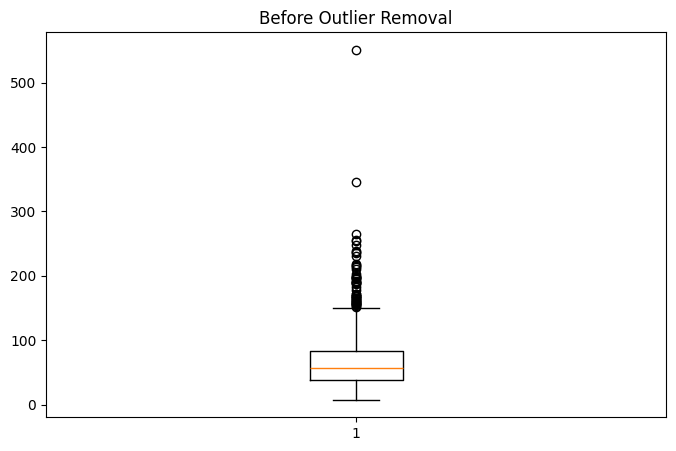

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(sales["amount"])

plt.title("Before Outlier Removal")

plt.show()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

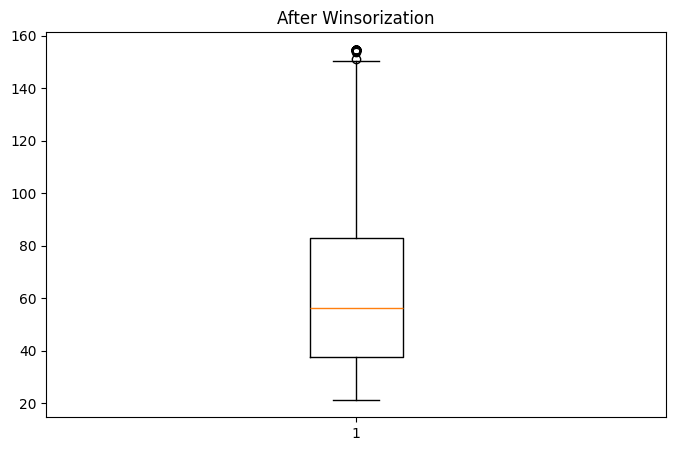

In [26]:
plt.figure(figsize=(8,5))

plt.boxplot(sales["amount_winsor"])

plt.title("After Winsorization")

plt.show()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [27]:
sales["day"] = sales["date"].dt.day
sales["month"] = sales["date"].dt.month
sales["year"] = sales["date"].dt.year

sales.head()

,transaction_id,user_id,product_id,amount,payment_type,date,amount_winsor,day,month,year
0,T000001,U0024,P015,67.67,Wallet,2023-02-12,67.67,12,2,2023
1,T000002,U0196,P044,76.44,UPI,2023-03-24,76.44,24,3,2023
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21,104.57,21,8,2025
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23,102.75,23,7,2024
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04,23.89,4,10,2025


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Replace "gender" with your binary column name
if "gender" in users.columns:
    users["gender"] = le.fit_transform(users["gender"])

# Replace "membership" with your binary column if available
if "membership" in users.columns:
    users["membership"] = le.fit_transform(users["membership"])

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [29]:
sales = pd.get_dummies(
    sales,
    columns=["payment_type"],
    drop_first=True
)

sales.head()

,transaction_id,user_id,product_id,amount,date,amount_winsor,day,month,year,payment_type_Credit Card,payment_type_Debit Card,payment_type_Net Banking,payment_type_UPI,payment_type_Wallet
0,T000001,U0024,P015,67.67,2023-02-12,67.67,12,2,2023,False,False,False,False,True
1,T000002,U0196,P044,76.44,2023-03-24,76.44,24,3,2023,False,False,False,True,False
2,T000003,U0196,P049,104.57,2025-08-21,104.57,21,8,2025,False,True,False,False,False
3,T000004,U0133,P042,102.75,2024-07-23,102.75,23,7,2024,False,False,True,False,False
4,T000005,U0047,P038,23.89,2025-10-04,23.89,4,10,2025,False,False,True,False,False


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [30]:
from sklearn.preprocessing import OrdinalEncoder

if "customer_level" in users.columns:

    order = [["Low","Medium","High"]]

    oe = OrdinalEncoder(categories=order)

    users["customer_level"] = oe.fit_transform(
        users[["customer_level"]]
    )

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [31]:
sales["Spending_Group"] = pd.cut(
    sales["amount"],
    bins=[0,50,100,sales["amount"].max()],
    labels=["Low","Medium","High"]
)

sales.head()

,transaction_id,user_id,product_id,amount,date,amount_winsor,day,month,year,payment_type_Credit Card,payment_type_Debit Card,payment_type_Net Banking,payment_type_UPI,payment_type_Wallet,Spending_Group
0,T000001,U0024,P015,67.67,2023-02-12,67.67,12,2,2023,False,False,False,False,True,Medium
1,T000002,U0196,P044,76.44,2023-03-24,76.44,24,3,2023,False,False,False,True,False,Medium
2,T000003,U0196,P049,104.57,2025-08-21,104.57,21,8,2025,False,True,False,False,False,High
3,T000004,U0133,P042,102.75,2024-07-23,102.75,23,7,2024,False,False,True,False,False,High
4,T000005,U0047,P038,23.89,2025-10-04,23.89,4,10,2025,False,False,True,False,False,Low


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [32]:
sales["Spending_Group"].value_counts()

,count
Spending_Group,
Low,417
Medium,412
High,171


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [33]:
sales["amount_log"] = np.log1p(sales["amount"])

sales[["amount","amount_log"]].head()

,amount,amount_log
0,67.67,4.229312
1,76.44,4.349503
2,104.57,4.659374
3,102.75,4.641984
4,23.89,3.214466


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [34]:
sales["amount_sqrt"] = np.sqrt(sales["amount"])

sales[["amount","amount_sqrt"]].head()

,amount,amount_sqrt
0,67.67,8.226178
1,76.44,8.742997
2,104.57,10.225947
3,102.75,10.136567
4,23.89,4.887740


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [35]:
sales[
    [
        "amount",
        "amount_log",
        "amount_sqrt"
    ]
].describe()

,amount,amount_log,amount_sqrt
count,1000.000000,1000.000000,1000.000000
mean,67.599040,4.053410,7.856346
std,45.411375,0.587302,2.425437
min,7.810000,2.175887,2.794638
25%,37.745000,3.656999,6.143691
50%,56.390000,4.049870,7.509326
75%,82.935000,4.430043,9.106865
max,550.950000,6.313457,23.472324


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

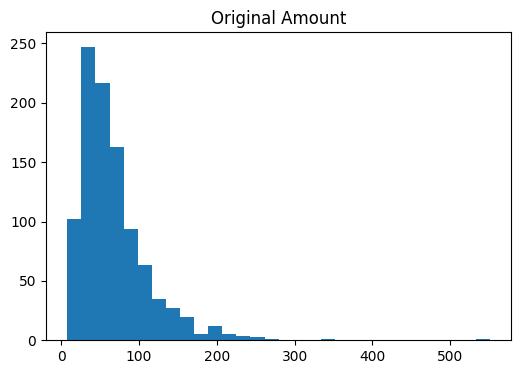

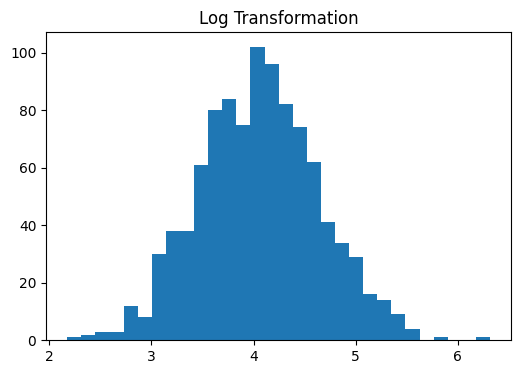

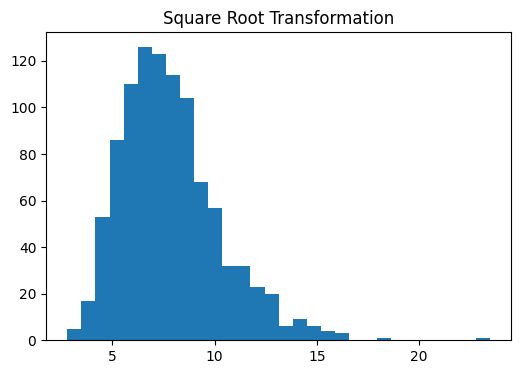

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(sales["amount"], bins=30)
plt.title("Original Amount")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(sales["amount_log"], bins=30)
plt.title("Log Transformation")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(sales["amount_sqrt"], bins=30)
plt.title("Square Root Transformation")
plt.show()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [37]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select only numerical columns from sales dataset
num_cols = sales.select_dtypes(include=np.number).columns

print(num_cols)

Index(['amount', 'amount_winsor', 'day', 'month', 'year', 'amount_log',
       'amount_sqrt'],
      dtype='object')


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [38]:
standard_scaler = StandardScaler()

sales_standard = sales.copy()

sales_standard[num_cols] = standard_scaler.fit_transform(
    sales_standard[num_cols]
)

sales_standard.head()

,transaction_id,user_id,product_id,amount,date,amount_winsor,day,month,year,payment_type_Credit Card,payment_type_Debit Card,payment_type_Net Banking,payment_type_UPI,payment_type_Wallet,Spending_Group,amount_log,amount_sqrt
0,T000001,U0024,P015,0.001563,2023-02-12,0.061147,-0.391779,-1.320486,-1.183909,False,False,False,False,True,Medium,0.299660,0.152557
1,T000002,U0196,P044,0.194783,2023-03-24,0.302443,0.926603,-1.015594,-1.183909,False,False,False,True,False,Medium,0.504412,0.365746
2,T000003,U0196,P049,0.814542,2025-08-21,1.076408,0.597007,0.508864,1.274884,False,True,False,False,False,High,1.032294,0.977468
3,T000004,U0133,P042,0.774444,2024-07-23,1.026332,0.816737,0.203973,0.045488,False,False,True,False,False,High,1.002669,0.940598
4,T000005,U0047,P038,-0.962995,2025-10-04,-1.143409,-1.270700,1.118648,1.274884,False,False,True,False,False,Low,-1.429185,-1.224560


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [39]:
minmax_scaler = MinMaxScaler()

sales_minmax = sales.copy()

sales_minmax[num_cols] = minmax_scaler.fit_transform(
    sales_minmax[num_cols]
)

sales_minmax.head()

,transaction_id,user_id,product_id,amount,date,amount_winsor,day,month,year,payment_type_Credit Card,payment_type_Debit Card,payment_type_Net Banking,payment_type_UPI,payment_type_Wallet,Spending_Group,amount_log,amount_sqrt
0,T000001,U0024,P015,0.110211,2023-02-12,0.347673,0.366667,0.090909,0.0,False,False,False,False,True,Medium,0.496288,0.262676
1,T000002,U0196,P044,0.126358,2023-03-24,0.413400,0.766667,0.181818,0.0,False,False,False,True,False,Medium,0.525336,0.287670
2,T000003,U0196,P049,0.178149,2025-08-21,0.624222,0.666667,0.636364,1.0,False,True,False,False,False,High,0.600228,0.359388
3,T000004,U0133,P042,0.174798,2024-07-23,0.610582,0.733333,0.545455,0.5,False,False,True,False,False,High,0.596025,0.355065
4,T000005,U0047,P038,0.029606,2025-10-04,0.019561,0.100000,0.818182,1.0,False,False,True,False,False,Low,0.251012,0.101225


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [40]:
print("Original Dataset")

display(sales[num_cols].describe())

print("Standard Scaled Dataset")

display(sales_standard[num_cols].describe())

Original Dataset


,amount,amount_winsor,day,month,year,amount_log,amount_sqrt
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,67.599040,65.447590,15.566000,6.331000,2023.963000,4.053410,7.856346
std,45.411375,36.363538,9.106623,3.281495,0.813814,0.587302,2.425437
min,7.810000,21.280000,1.000000,1.000000,2023.000000,2.175887,2.794638
25%,37.745000,37.745000,8.000000,4.000000,2023.000000,3.656999,6.143691
50%,56.390000,56.390000,15.000000,6.000000,2024.000000,4.049870,7.509326
75%,82.935000,82.935000,24.000000,9.000000,2025.000000,4.430043,9.106865
max,550.950000,154.710000,31.000000,12.000000,2025.000000,6.313457,23.472324


Standard Scaled Dataset


,amount,amount_winsor,day,month,year,amount_log,amount_sqrt
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-3.730349e-17,-1.278977e-16,-7.815970e-17,-1.261213e-16,4.247980e-14,-6.856737e-16,7.460699e-17
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.317268e+00,-1.215220e+00,-1.600296e+00,-1.625377e+00,-1.183909e+00,-3.198460e+00,-2.087971e+00
25%,-6.577422e-01,-7.622045e-01,-8.312397e-01,-7.107025e-01,-1.183909e+00,-6.753073e-01,-7.064758e-01
50%,-2.469568e-01,-2.492090e-01,-6.218367e-02,-1.009191e-01,4.548768e-02,-6.030541e-03,-1.431469e-01
75%,3.378808e-01,4.811457e-01,9.266026e-01,8.137559e-01,1.274884e+00,6.416148e-01,5.158430e-01
max,1.064916e+01,2.455951e+00,1.695659e+00,1.728431e+00,1.274884e+00,3.850114e+00,6.441641e+00


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [41]:
print("Original Dataset")

display(sales[num_cols].describe())

print("MinMax Scaled Dataset")

display(sales_minmax[num_cols].describe())

Original Dataset


,amount,amount_winsor,day,month,year,amount_log,amount_sqrt
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,67.599040,65.447590,15.566000,6.331000,2023.963000,4.053410,7.856346
std,45.411375,36.363538,9.106623,3.281495,0.813814,0.587302,2.425437
min,7.810000,21.280000,1.000000,1.000000,2023.000000,2.175887,2.794638
25%,37.745000,37.745000,8.000000,4.000000,2023.000000,3.656999,6.143691
50%,56.390000,56.390000,15.000000,6.000000,2024.000000,4.049870,7.509326
75%,82.935000,82.935000,24.000000,9.000000,2025.000000,4.430043,9.106865
max,550.950000,154.710000,31.000000,12.000000,2025.000000,6.313457,23.472324


MinMax Scaled Dataset


,amount,amount_winsor,day,month,year,amount_log,amount_sqrt
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.110080,0.331017,0.485533,0.484636,0.481500,0.453774,0.244791
std,0.083609,0.272529,0.303554,0.298318,0.406907,0.141944,0.117297
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.055115,0.123398,0.233333,0.272727,0.000000,0.357966,0.161965
50%,0.089443,0.263134,0.466667,0.454545,0.500000,0.452919,0.228009
75%,0.138316,0.462077,0.766667,0.727273,1.000000,0.544802,0.305268
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

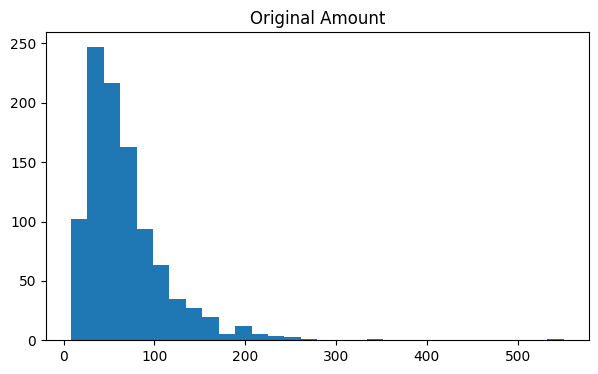

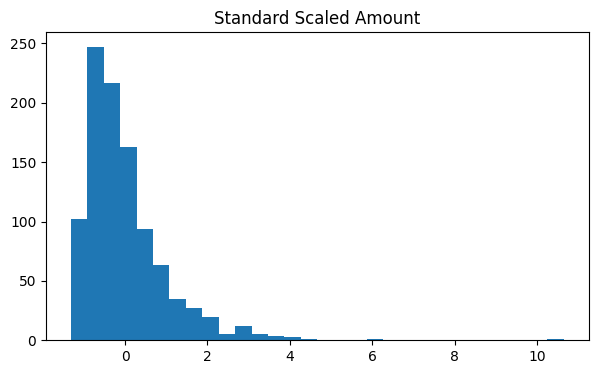

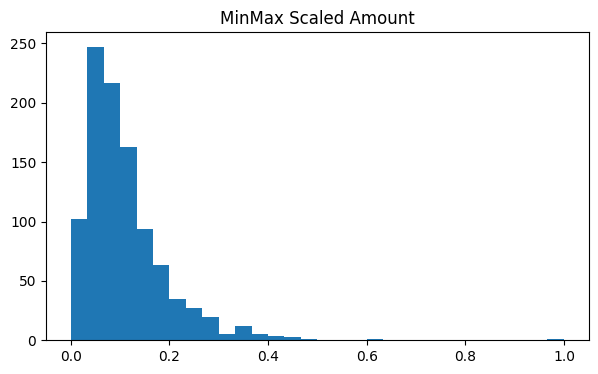

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(sales["amount"], bins=30)
plt.title("Original Amount")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(sales_standard["amount"], bins=30)
plt.title("Standard Scaled Amount")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(sales_minmax["amount"], bins=30)
plt.title("MinMax Scaled Amount")
plt.show()

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [43]:
# Extract Year-Month
sales["YearMonth"] = sales["date"].dt.to_period("M")

# Monthly spend per customer
monthly_spend = (
    sales.groupby(["user_id", "YearMonth"])["amount"]
    .sum()
    .reset_index(name="Monthly_Spend")
)

# Average monthly spend
avg_monthly_spend = (
    monthly_spend.groupby("user_id")["Monthly_Spend"]
    .mean()
    .reset_index(name="Avg_Monthly_Spend")
)

avg_monthly_spend.head()

,user_id,Avg_Monthly_Spend
0,U0001,77.473333
1,U0002,129.680000
2,U0003,40.597500
3,U0004,100.213333
4,U0005,57.948333


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [44]:
purchase_frequency = (
    sales.groupby("user_id")
    .size()
    .reset_index(name="Purchase_Frequency")
)

purchase_frequency.head()

,user_id,Purchase_Frequency
0,U0001,3
1,U0002,6
2,U0003,4
3,U0004,3
4,U0005,6


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [45]:
latest_date = sales["date"].max()

last_purchase = (
    sales.groupby("user_id")["date"]
    .max()
    .reset_index()
)

last_purchase["Days_Since_Last_Purchase"] = (
    latest_date - last_purchase["date"]
).dt.days

last_purchase.head()

,user_id,date,Days_Since_Last_Purchase
0,U0001,2024-08-20,438
1,U0002,2024-04-27,553
2,U0003,2025-11-01,0
3,U0004,2024-04-03,577
4,U0005,2025-06-22,132


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [46]:
sales_inventory = pd.merge(
    sales,
    inventory,
    on="product_id",
    how="left"
)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [47]:
category_expenditure = (
    sales_inventory.groupby("category")["amount"]
    .sum()
    .reset_index(name="Category_Total_Expenditure")
)

category_expenditure.head()

,category,Category_Total_Expenditure
0,Beauty,8079.73
1,Books,12529.84
2,Clothing,9080.87
3,Electronics,5616.05
4,Grocery,8427.07


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [48]:
customer_features = (
    avg_monthly_spend
    .merge(purchase_frequency, on="user_id", how="left")
    .merge(last_purchase[["user_id", "Days_Since_Last_Purchase"]], on="user_id", how="left")
)

customer_features.head()

,user_id,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase
0,U0001,77.473333,3,438
1,U0002,129.680000,6,553
2,U0003,40.597500,4,0
3,U0004,100.213333,3,577
4,U0005,57.948333,6,132


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [49]:
final_users = pd.merge(
    users,
    customer_features,
    on="user_id",
    how="left"
)

final_users.head()

,user_id,name,age,gender,city,registration_date,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase
0,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438
1,U0002,Sai Reddy,30.0,2,Hyderabad,2023-11-24,129.680000,6,553
2,U0003,Aarohi Gupta,37.0,2,Indore,2022-02-02,40.597500,4,0
3,U0004,Aarav Gupta,44.0,1,Kolkata,2023-06-02,100.213333,3,577
4,U0005,Sara Sharma,30.0,2,Chennai,2024-01-04,57.948333,6,132


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [50]:
print("Number of Features :", final_users.shape[1])

print("Number of Records :", final_users.shape[0])

final_users.head()

Number of Features : 9
Number of Records : 200


,user_id,name,age,gender,city,registration_date,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase
0,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438
1,U0002,Sai Reddy,30.0,2,Hyderabad,2023-11-24,129.680000,6,553
2,U0003,Aarohi Gupta,37.0,2,Indore,2022-02-02,40.597500,4,0
3,U0004,Aarav Gupta,44.0,1,Kolkata,2023-06-02,100.213333,3,577
4,U0005,Sara Sharma,30.0,2,Chennai,2024-01-04,57.948333,6,132


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [51]:
print("Number of Features :", final_users.shape[1])

print("Number of Records :", final_users.shape[0])

final_users.head()

Number of Features : 9
Number of Records : 200


,user_id,name,age,gender,city,registration_date,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase
0,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438
1,U0002,Sai Reddy,30.0,2,Hyderabad,2023-11-24,129.680000,6,553
2,U0003,Aarohi Gupta,37.0,2,Indore,2022-02-02,40.597500,4,0
3,U0004,Aarav Gupta,44.0,1,Kolkata,2023-06-02,100.213333,3,577
4,U0005,Sara Sharma,30.0,2,Chennai,2024-01-04,57.948333,6,132


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [52]:
# Merge users with sales
final_dataset = pd.merge(
    final_users,
    sales,
    on="user_id",
    how="left"
)

# Merge with inventory
final_dataset = pd.merge(
    final_dataset,
    inventory,
    on="product_id",
    how="left"
)

final_dataset.head()

,user_id,name,age,gender,city,registration_date,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase,transaction_id,...,payment_type_UPI,payment_type_Wallet,Spending_Group,amount_log,amount_sqrt,YearMonth,product_name,category,price,stock
0,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438,T000237,...,True,False,High,4.984017,12.044086,2024-05,Product_040,Grocery,4011.76,36.0
1,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438,T000629,...,False,False,Low,3.771150,6.513831,2023-06,Product_014,Beauty,3844.95,467.0
2,U0001,Vihaan Sharma,35.0,2,Jaipur,2022-09-08,77.473333,3,438,T000960,...,True,False,Low,3.827118,6.702984,2024-08,Product_022,Electronics,3207.91,466.0
3,U0002,Sai Reddy,30.0,2,Hyderabad,2023-11-24,129.680000,6,553,T000153,...,True,False,Medium,4.525477,9.557196,2024-03,Product_014,Beauty,3844.95,467.0
4,U0002,Sai Reddy,30.0,2,Hyderabad,2023-11-24,129.680000,6,553,T000390,...,False,False,Low,3.516607,5.715768,2024-04,Product_017,Beauty,3697.53,235.0


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [53]:
drop_cols = [
    "user_id",
    "transaction_id",
    "name",
    "registration_date",
    "date",
    "YearMonth",
    "product_name"
]

final_dataset.drop(columns=drop_cols, inplace=True)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [54]:
bool_cols = final_dataset.select_dtypes(include="bool").columns

final_dataset[bool_cols] = final_dataset[bool_cols].astype(int)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [55]:
categorical_cols = final_dataset.select_dtypes(include="object").columns

final_dataset = pd.get_dummies(
    final_dataset,
    columns=categorical_cols,
    drop_first=True
)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = final_dataset.select_dtypes(include=["int64","float64"]).columns

final_dataset[num_cols] = scaler.fit_transform(final_dataset[num_cols])

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [57]:
final_dataset

,age,gender,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase,amount,amount_winsor,day,month,year,...,product_id_P048,product_id_P049,product_id_P050,category_Books,category_Clothing,category_Electronics,category_Grocery,category_Home,category_Sports,category_Toys
0,0.516262,1.258384,0.165309,-1.248667,1.821244,1.706615,2.190443,7,5,2024,...,False,False,False,False,False,False,True,False,False,False
1,0.516262,1.258384,0.165309,-1.248667,1.821244,-0.554523,-0.633302,9,6,2023,...,False,False,False,False,False,False,False,False,False,False
2,0.516262,1.258384,0.165309,-1.248667,1.821244,-0.499443,-0.564518,20,8,2024,...,False,False,False,False,False,True,False,False,False,False
3,-0.177452,1.258384,2.441422,0.021164,2.578091,0.523059,0.712399,8,3,2024,...,False,False,False,False,False,False,False,False,False,False
4,-0.177452,1.258384,2.441422,0.021164,2.578091,-0.769554,-0.901837,27,4,2024,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.127145,0.217976,9,9,2024,...,False,False,False,False,False,False,True,False,False,False
996,-1.287395,1.258384,-0.720823,0.021164,-0.607248,-0.931269,-1.103789,24,8,2025,...,False,False,False,False,False,True,False,False,False,False
997,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.284233,0.414150,1,3,2023,...,False,False,False,True,False,False,False,False,False,False
998,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.289741,0.421028,19,1,2023,...,False,False,True,False,False,False,False,False,False,True


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [58]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns
print(bool_cols)

Index(['city_Bengaluru', 'city_Bhopal', 'city_Chennai', 'city_Delhi',
       'city_Ghaziabad', 'city_Hyderabad', 'city_Indore', 'city_Jaipur',
       'city_Kanpur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai',
       'city_Nagpur', 'city_Patna', 'city_Pune', 'city_Surat', 'city_Thane',
       'city_Vadodara', 'city_Visakhapatnam', 'product_id_P002',
       'product_id_P003', 'product_id_P004', 'product_id_P005',
       'product_id_P006', 'product_id_P007', 'product_id_P008',
       'product_id_P009', 'product_id_P010', 'product_id_P011',
       'product_id_P012', 'product_id_P013', 'product_id_P014',
       'product_id_P015', 'product_id_P016', 'product_id_P017',
       'product_id_P018', 'product_id_P019', 'product_id_P020',
       'product_id_P021', 'product_id_P022', 'product_id_P023',
       'product_id_P024', 'product_id_P025', 'product_id_P026',
       'product_id_P027', 'product_id_P028', 'product_id_P029',
       'product_id_P030', 'product_id_P031', 'product_id_P032',
      

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [59]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns

final_dataset[bool_cols] = final_dataset[bool_cols].astype(int)

**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [60]:
final_dataset

,age,gender,Avg_Monthly_Spend,Purchase_Frequency,Days_Since_Last_Purchase,amount,amount_winsor,day,month,year,...,product_id_P048,product_id_P049,product_id_P050,category_Books,category_Clothing,category_Electronics,category_Grocery,category_Home,category_Sports,category_Toys
0,0.516262,1.258384,0.165309,-1.248667,1.821244,1.706615,2.190443,7,5,2024,...,0,0,0,0,0,0,1,0,0,0
1,0.516262,1.258384,0.165309,-1.248667,1.821244,-0.554523,-0.633302,9,6,2023,...,0,0,0,0,0,0,0,0,0,0
2,0.516262,1.258384,0.165309,-1.248667,1.821244,-0.499443,-0.564518,20,8,2024,...,0,0,0,0,0,1,0,0,0,0
3,-0.177452,1.258384,2.441422,0.021164,2.578091,0.523059,0.712399,8,3,2024,...,0,0,0,0,0,0,0,0,0,0
4,-0.177452,1.258384,2.441422,0.021164,2.578091,-0.769554,-0.901837,27,4,2024,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.127145,0.217976,9,9,2024,...,0,0,0,0,0,0,1,0,0,0
996,-1.287395,1.258384,-0.720823,0.021164,-0.607248,-0.931269,-1.103789,24,8,2025,...,0,0,0,0,0,1,0,0,0,0
997,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.284233,0.414150,1,3,2023,...,0,0,0,1,0,0,0,0,0,0
998,-1.287395,1.258384,-0.720823,0.021164,-0.607248,0.289741,0.421028,19,1,2023,...,0,0,1,0,0,0,0,0,0,1


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [61]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns
print(bool_cols)

Index([], dtype='object')


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [62]:
original_features = users.shape[1]

final_features = final_dataset.shape[1]

print("Original Features :", original_features)

print("Final Features :", final_features)

print("New Features Created :", final_features - original_features)

Original Features : 6
Final Features : 95
New Features Created : 89


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [63]:
Q1 = sales["amount"].quantile(0.25)
Q3 = sales["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_outliers = sales[
    (sales["amount"] < lower) |
    (sales["amount"] > upper)
]

print("Outliers Before :", len(before_outliers))

Outliers Before : 53


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [64]:
Q1 = sales_iqr["amount"].quantile(0.25)
Q3 = sales_iqr["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

after_outliers = sales_iqr[
    (sales_iqr["amount"] < lower) |
    (sales_iqr["amount"] > upper)
]

print("Outliers After :", len(after_outliers))

Outliers After : 13


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [65]:
print("="*50)

print("FINAL REPORT")

print("="*50)

print("Records Before Cleaning :", len(sales))

print("Records After Cleaning :", len(sales_iqr))

print("Features Created :", final_features-original_features)

print("Remaining Missing Values")

print(final_dataset.isnull().sum().sum())

print("Outliers Before :", len(before_outliers))

print("Outliers After :", len(after_outliers))

print("="*50)

FINAL REPORT
Records Before Cleaning : 1000
Records After Cleaning : 947
Features Created : 89
Remaining Missing Values
0
Outliers Before : 53
Outliers After : 13


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.

In [66]:
final_dataset.to_csv(
    "final_cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


**Explanation:** This code cell performs the next preprocessing step in the workflow. Run this cell to execute the operations shown above and continue with the data preparation pipeline.